In [1]:
# ── Imports ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported ✅")

All libraries imported ✅


In [3]:
# CSV file Colab mein upload karo
from google.colab import files
uploaded = files.upload()

Saving vix-daily.csv to vix-daily.csv


In [4]:
# ── Load Data ──
df = pd.read_csv("vix-daily.csv")
df["DATE"]    = pd.to_datetime(df["DATE"])
df["Year"]    = df["DATE"].dt.year
df["Month"]   = df["DATE"].dt.month
df["Decade"]  = (df["Year"] // 10 * 10).astype(str) + "s"
df["MA_30"]   = df["CLOSE"].rolling(30).mean()
df["MA_252"]  = df["CLOSE"].rolling(252).mean()
df["Zone"]    = pd.cut(df["CLOSE"], bins=[0,15,25,35,9999],
                labels=["Low (<15)","Normal (15-25)","High (25-35)","Extreme (>35)"])
print("Shape:", df.shape)
df.head()

Shape: (9190, 11)


,DATE,OPEN,HIGH,LOW,CLOSE,Year,Month,Decade,MA_30,MA_252,Zone
0,1990-01-02,17.24,17.24,17.24,17.24,1990,1,1990s,NaN,NaN,Normal (15-25)
1,1990-01-03,18.19,18.19,18.19,18.19,1990,1,1990s,NaN,NaN,Normal (15-25)
2,1990-01-04,19.22,19.22,19.22,19.22,1990,1,1990s,NaN,NaN,Normal (15-25)
3,1990-01-05,20.11,20.11,20.11,20.11,1990,1,1990s,NaN,NaN,Normal (15-25)
4,1990-01-08,20.26,20.26,20.26,20.26,1990,1,1990s,NaN,NaN,Normal (15-25)


In [5]:
# ── Data Info & Cleaning Check ──
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Statistics ===")
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9190 entries, 0 to 9189
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    9190 non-null   datetime64[ns]
 1   OPEN    9190 non-null   float64       
 2   HIGH    9190 non-null   float64       
 3   LOW     9190 non-null   float64       
 4   CLOSE   9190 non-null   float64       
 5   Year    9190 non-null   int32         
 6   Month   9190 non-null   int32         
 7   Decade  9190 non-null   object        
 8   MA_30   9161 non-null   float64       
 9   MA_252  8939 non-null   float64       
 10  Zone    9190 non-null   category      
dtypes: category(1), datetime64[ns](1), float64(6), int32(2), object(1)
memory usage: 655.5+ KB
None

=== Missing Values ===
DATE        0
OPEN        0
HIGH        0
LOW         0
CLOSE       0
Year        0
Month       0
Decade      0
MA_30      29
MA_252    251
Zone        0
dtype: int64

=== Bas

,DATE,OPEN,HIGH,LOW,CLOSE,Year,Month,MA_30,MA_252
count,9190,9190.00,9190.00,9190.00,9190.00,9190.00,9190.00,9161.00,8939.00
mean,2008-03-24 18:55:23.438520320,19.55,20.38,18.77,19.45,2007.73,6.50,19.45,19.43
min,1990-01-02 00:00:00,2.58,9.31,8.56,9.14,1990.00,1.00,9.95,11.01
25%,1999-02-08 06:00:00,14.00,14.63,13.49,13.96,1999.00,4.00,14.18,14.56
50%,2008-03-29 12:00:00,17.68,18.38,17.04,17.62,2008.00,6.00,17.53,18.02
75%,2017-05-11 18:00:00,22.89,23.76,22.05,22.73,2017.00,9.00,22.98,23.52
max,2026-05-21 00:00:00,82.69,89.53,72.76,82.69,2026.00,12.00,64.99,41.04
std,NaN,7.83,8.31,7.28,7.75,10.53,3.43,7.24,5.79


In [6]:
# ── Key Insights ──
print("Date Range:", df["DATE"].min().date(), "to", df["DATE"].max().date())
print("Total Trading Days:", len(df))
print("Max VIX:", df["CLOSE"].max(), "on", df.loc[df["CLOSE"].idxmax(), "DATE"].date())
print("Min VIX:", df["CLOSE"].min(), "on", df.loc[df["CLOSE"].idxmin(), "DATE"].date())
print("Mean VIX:", round(df["CLOSE"].mean(), 2))
print("\nZone Distribution:")
print(df["Zone"].value_counts())

Date Range: 1990-01-02 to 2026-05-21
Total Trading Days: 9190
Max VIX: 82.69 on 2020-03-16
Min VIX: 9.14 on 2017-11-03
Mean VIX: 19.45

Zone Distribution:
Zone
Normal (15-25)    4627
Low (<15)         2962
High (25-35)      1248
Extreme (>35)      353
Name: count, dtype: int64


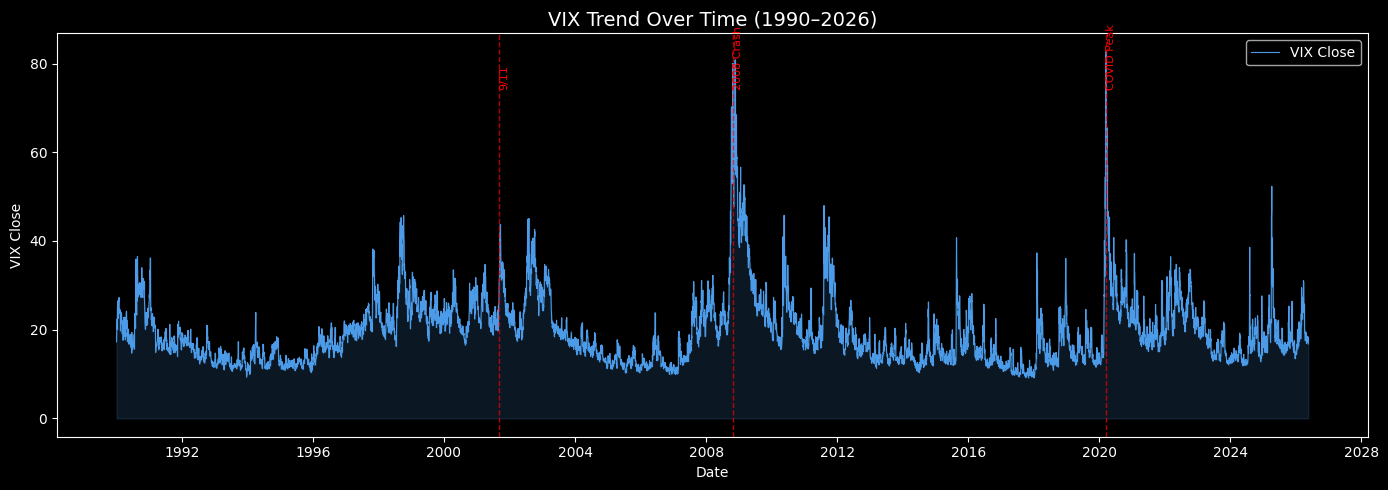

In [7]:
# ── Chart 1: VIX Trend (Matplotlib) ──
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(df["DATE"], df["CLOSE"], color="#4C9BE8", linewidth=0.8, label="VIX Close")
ax.fill_between(df["DATE"], df["CLOSE"], alpha=0.15, color="#4C9BE8")
crises = [("2008-10-24","2008 Crash"),("2020-03-16","COVID Peak"),("2001-09-11","9/11")]
for d, lbl in crises:
    ax.axvline(pd.to_datetime(d), color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(pd.to_datetime(d), df["CLOSE"].max()*0.9, lbl, color="red", fontsize=8, rotation=90)
ax.set_title("VIX Trend Over Time (1990–2026)", fontsize=14)
ax.set_xlabel("Date"); ax.set_ylabel("VIX Close")
ax.legend(); plt.tight_layout(); plt.show()

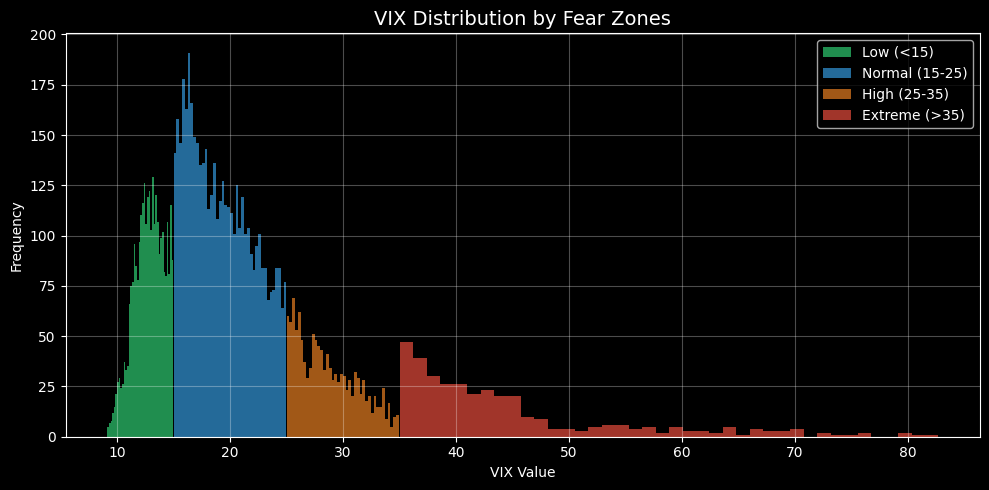

In [8]:
# ── Chart 2: Distribution Histogram (Seaborn) ──
fig, ax = plt.subplots(figsize=(10,5))
colors = {"Low (<15)":"#2ecc71","Normal (15-25)":"#3498db",
          "High (25-35)":"#e67e22","Extreme (>35)":"#e74c3c"}
for zone, color in colors.items():
    subset = df[df["Zone"]==zone]["CLOSE"]
    ax.hist(subset, bins=40, alpha=0.7, color=color, label=zone)
ax.set_title("VIX Distribution by Fear Zones", fontsize=14)
ax.set_xlabel("VIX Value"); ax.set_ylabel("Frequency")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

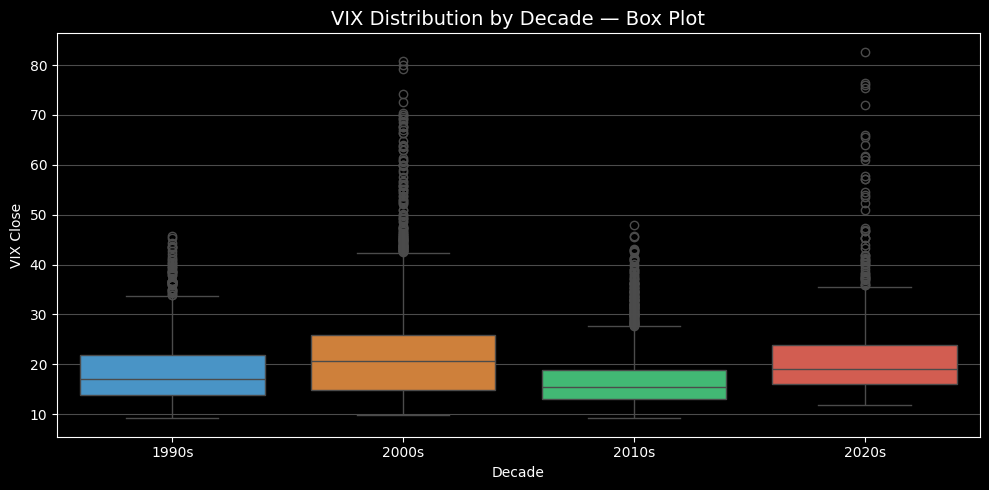

In [9]:
# ── Chart 3: Box Plot by Decade (Seaborn) ──
fig, ax = plt.subplots(figsize=(10,5))
palette = {"1990s":"#3498db","2000s":"#e67e22","2010s":"#2ecc71","2020s":"#e74c3c"}
sns.boxplot(data=df, x="Decade", y="CLOSE", palette=palette, ax=ax)
ax.set_title("VIX Distribution by Decade — Box Plot", fontsize=14)
ax.set_xlabel("Decade"); ax.set_ylabel("VIX Close")
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

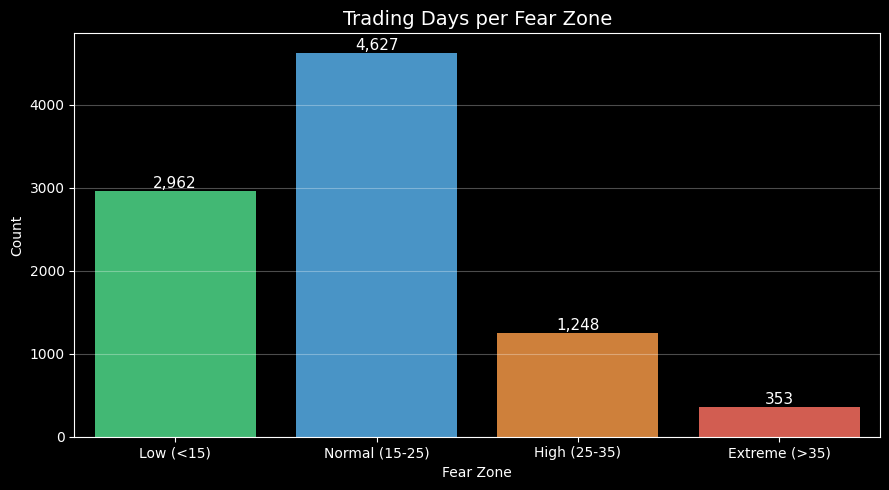

In [10]:
# ── Chart 4: Count Plot (Seaborn) ──
fig, ax = plt.subplots(figsize=(9,5))
zone_order = ["Low (<15)","Normal (15-25)","High (25-35)","Extreme (>35)"]
sns.countplot(data=df, x="Zone", order=zone_order,
              palette=["#2ecc71","#3498db","#e67e22","#e74c3c"], ax=ax)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
ax.set_title("Trading Days per Fear Zone", fontsize=14)
ax.set_xlabel("Fear Zone"); ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

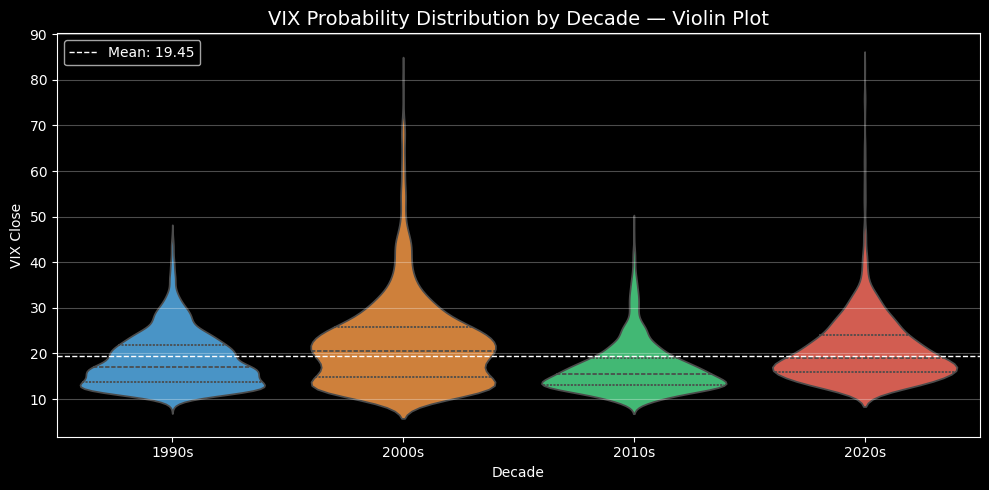

In [11]:
# ── Chart 5: Violin Plot (Seaborn) ──
fig, ax = plt.subplots(figsize=(10,5))
palette = {"1990s":"#3498db","2000s":"#e67e22","2010s":"#2ecc71","2020s":"#e74c3c"}
sns.violinplot(data=df, x="Decade", y="CLOSE", palette=palette,
               inner="quartile", ax=ax)
ax.set_title("VIX Probability Distribution by Decade — Violin Plot", fontsize=14)
ax.set_xlabel("Decade"); ax.set_ylabel("VIX Close")
ax.axhline(df["CLOSE"].mean(), color="white", linestyle="--",
           linewidth=1, label=f"Mean: {df['CLOSE'].mean():.2f}")
ax.legend(); ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

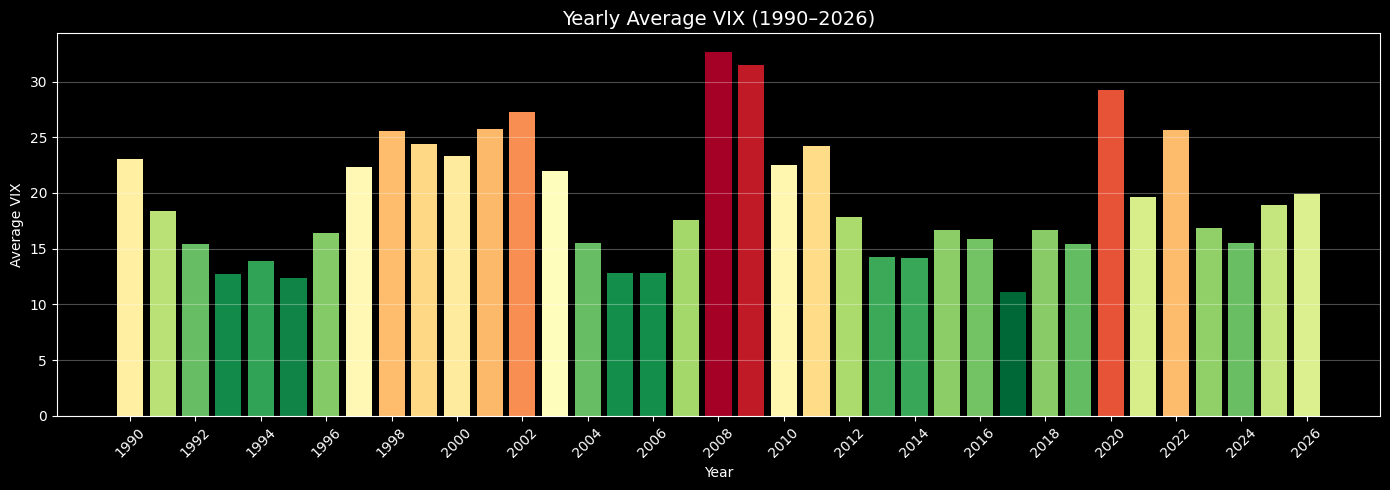

In [12]:
# ── Chart 6: Yearly Average Bar (Matplotlib) ──
yearly = df.groupby("Year")["CLOSE"].mean()
fig, ax = plt.subplots(figsize=(14,5))
bars = ax.bar(yearly.index, yearly.values, color=plt.cm.RdYlGn_r(
    (yearly.values - yearly.min())/(yearly.max()-yearly.min())))
ax.set_title("Yearly Average VIX (1990–2026)", fontsize=14)
ax.set_xlabel("Year"); ax.set_ylabel("Average VIX")
ax.set_xticks(yearly.index[::2]); ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

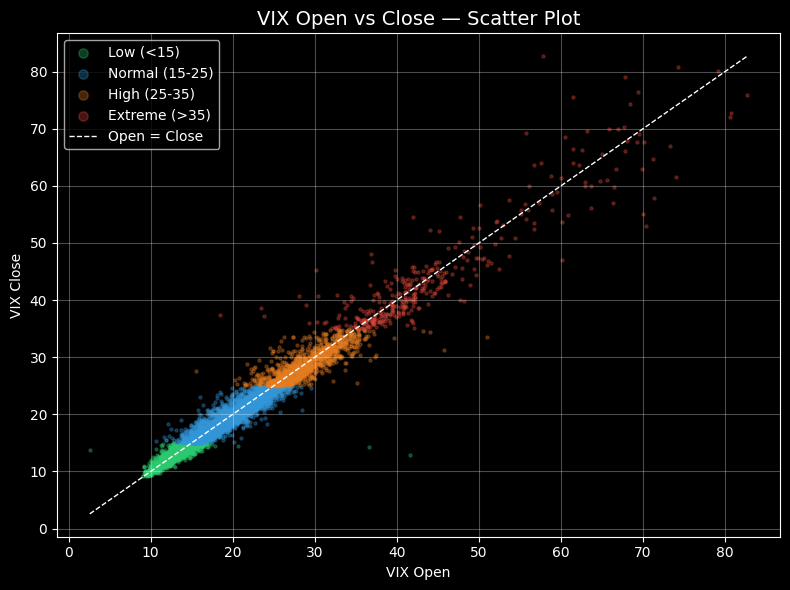

In [13]:
# ── Chart 7: Scatter Plot ──
fig, ax = plt.subplots(figsize=(8,6))
zone_colors = {"Low (<15)":"#2ecc71","Normal (15-25)":"#3498db",
               "High (25-35)":"#e67e22","Extreme (>35)":"#e74c3c"}
for zone, color in zone_colors.items():
    subset = df[df["Zone"]==zone]
    ax.scatter(subset["OPEN"], subset["CLOSE"], c=color, alpha=0.3,
               s=5, label=zone)
vmin = df[["OPEN","CLOSE"]].min().min()
vmax = df[["OPEN","CLOSE"]].max().max()
ax.plot([vmin,vmax],[vmin,vmax],"w--",linewidth=1,label="Open = Close")
ax.set_title("VIX Open vs Close — Scatter Plot", fontsize=14)
ax.set_xlabel("VIX Open"); ax.set_ylabel("VIX Close")
ax.legend(markerscale=3); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

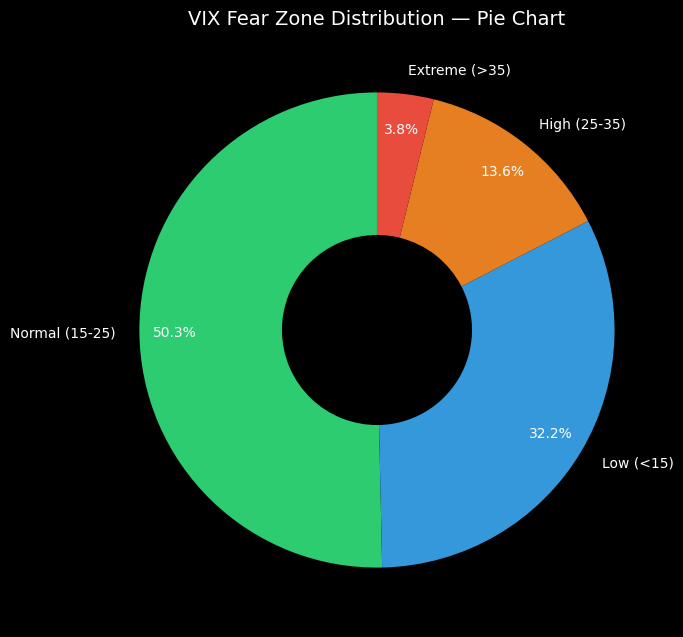

In [14]:
# ── Chart 8: Pie Chart ──
zone_counts = df["Zone"].value_counts()
colors = ["#2ecc71","#3498db","#e67e22","#e74c3c"]
fig, ax = plt.subplots(figsize=(7,7))
ax.pie(zone_counts.values, labels=zone_counts.index,
       colors=colors, autopct="%1.1f%%", startangle=90,
       pctdistance=0.85, wedgeprops=dict(width=0.6))
ax.set_title("VIX Fear Zone Distribution — Pie Chart", fontsize=14)
plt.tight_layout(); plt.show()

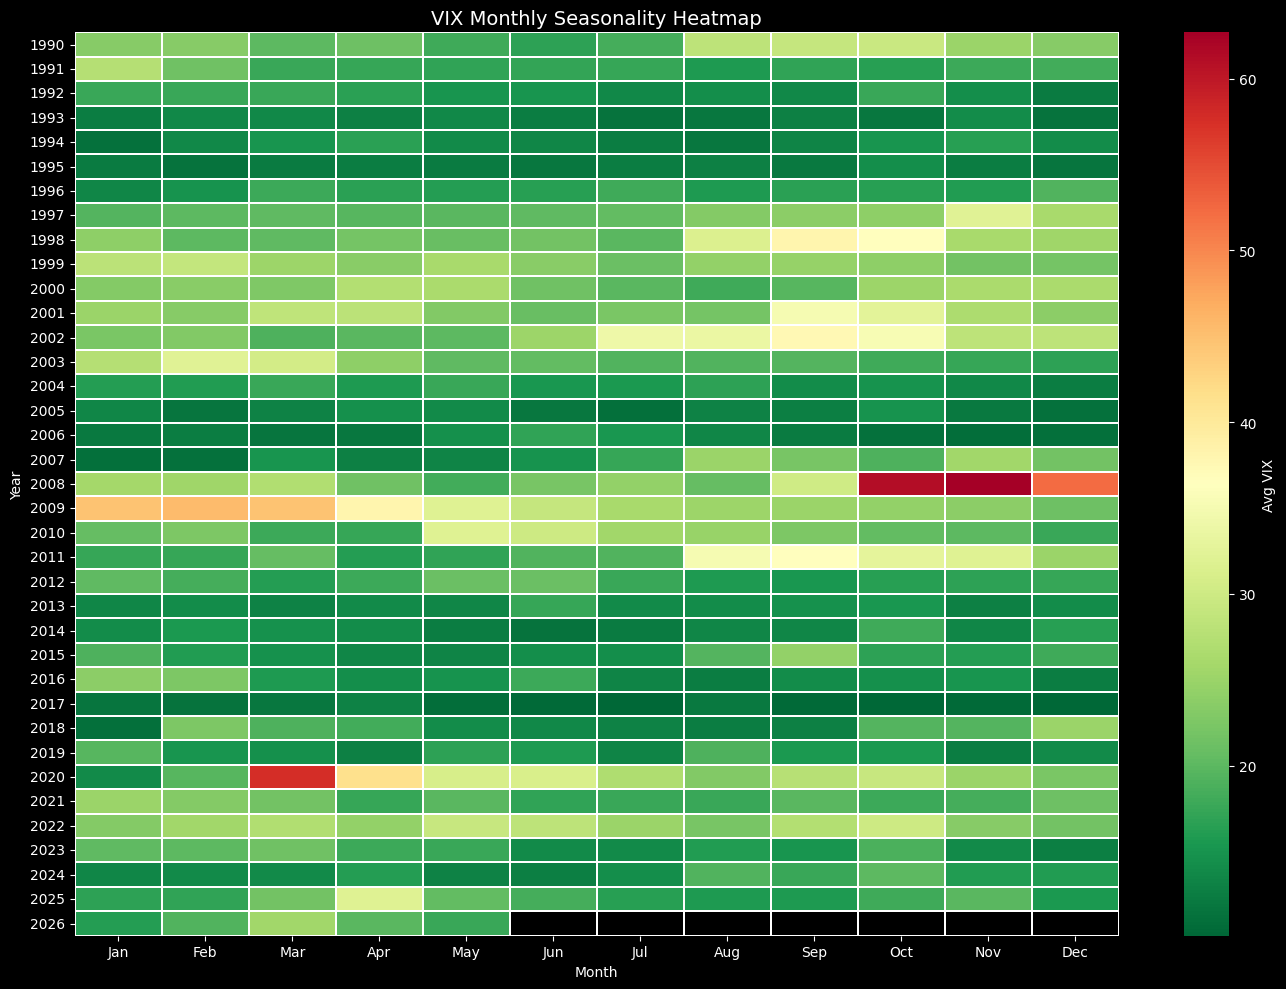

In [15]:
# ── Chart 9: Heatmap — Monthly Avg ──
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
             7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
pivot = df.pivot_table(values="CLOSE", index="Year",
                       columns="Month", aggfunc="mean").round(1)
pivot.columns = [month_map[m] for m in pivot.columns]
fig, ax = plt.subplots(figsize=(14,10))
sns.heatmap(pivot, cmap="RdYlGn_r", annot=False,
            linewidths=0.3, ax=ax, cbar_kws={"label":"Avg VIX"})
ax.set_title("VIX Monthly Seasonality Heatmap", fontsize=14)
ax.set_xlabel("Month"); ax.set_ylabel("Year")
plt.tight_layout(); plt.show()

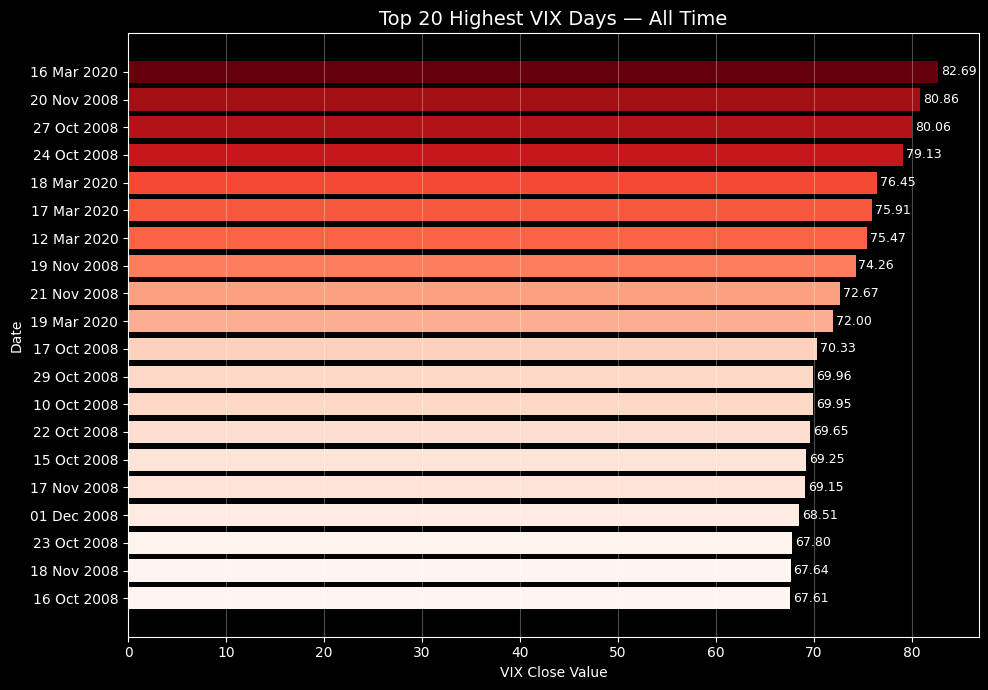

In [17]:
# ── Chart 10: Top 20 Highest VIX Days (Matplotlib) ──
top20 = df.nlargest(20, "CLOSE").sort_values("CLOSE", ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20["DATE"].dt.strftime("%d %b %Y"),
               top20["CLOSE"],
               color=plt.cm.Reds(
                   (top20["CLOSE"] - top20["CLOSE"].min()) /
                   (top20["CLOSE"].max() - top20["CLOSE"].min())
               ))
for bar, val in zip(bars, top20["CLOSE"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=9)
ax.set_title("Top 20 Highest VIX Days — All Time", fontsize=14)
ax.set_xlabel("VIX Close Value")
ax.set_ylabel("Date")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

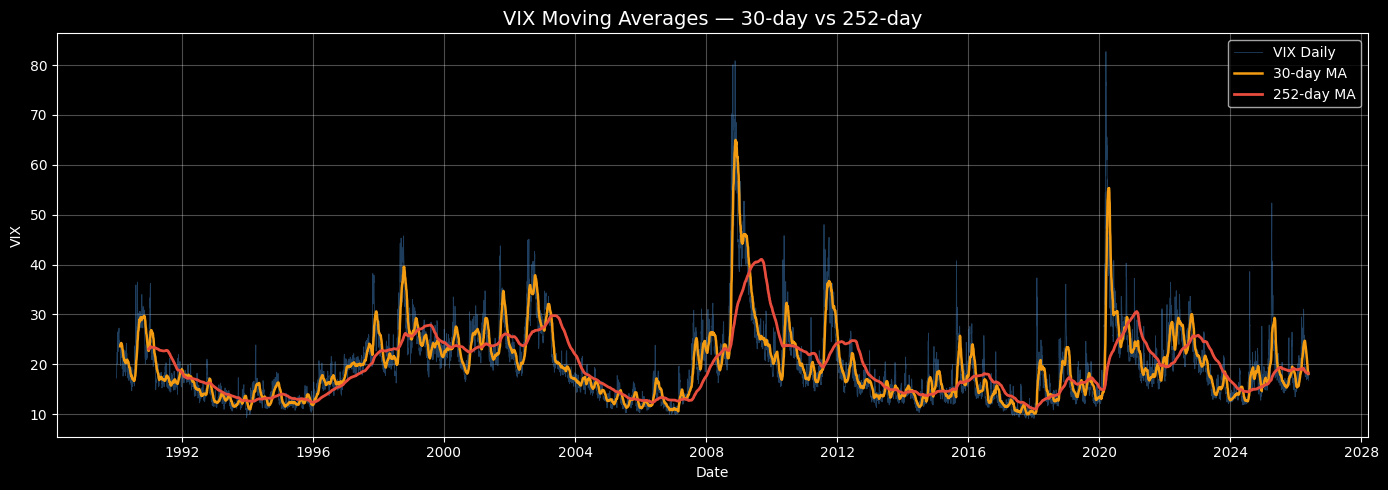

In [18]:
# ── Chart 11: Moving Averages (Matplotlib) ──
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["DATE"], df["CLOSE"], color="#4C9BE8",
        linewidth=0.6, alpha=0.4, label="VIX Daily")
ax.plot(df["DATE"], df["MA_30"], color="#f39c12",
        linewidth=1.8, label="30-day MA")
ax.plot(df["DATE"], df["MA_252"], color="#e74c3c",
        linewidth=2.0, label="252-day MA")
ax.set_title("VIX Moving Averages — 30-day vs 252-day", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("VIX")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# ── Final Insights Summary ──
print("=" * 50)
print("KEY INSIGHTS — VIX Fear Index EDA")
print("=" * 50)
print(f"1. Highest VIX: {df['CLOSE'].max():.2f} on {df.loc[df['CLOSE'].idxmax(),'DATE'].date()} (COVID-19)")
print(f"2. Lowest VIX:  {df['CLOSE'].min():.2f} on {df.loc[df['CLOSE'].idxmin(),'DATE'].date()}")
print(f"3. Average VIX: {df['CLOSE'].mean():.2f}")
print(f"4. Most volatile decade: {df.groupby('Decade')['CLOSE'].mean().idxmax()}")
print(f"5. Calmest year: {df.groupby('Year')['CLOSE'].mean().idxmin()}")
print(f"6. Most volatile year: {df.groupby('Year')['CLOSE'].mean().idxmax()}")
print(f"7. % days in Extreme zone: {(df['Zone']=='Extreme (>35)').mean()*100:.1f}%")
print(f"8. Most volatile month historically: Oct/Nov based on heatmap")

KEY INSIGHTS — VIX Fear Index EDA
1. Highest VIX: 82.69 on 2020-03-16 (COVID-19)
2. Lowest VIX:  9.14 on 2017-11-03
3. Average VIX: 19.45
4. Most volatile decade: 2000s
5. Calmest year: 2017
6. Most volatile year: 2008
7. % days in Extreme zone: 3.8%
8. Most volatile month historically: Oct/Nov based on heatmap
